# Phenotyping PEAS - Genotype Clustering and Validation (Phase 1)

Genotype selection (Phase 1) for green onion (*Allium fistulosum*) germplasm: clustering plus real statistical validation.

**Pipeline**: load & merge data -> scale (MinMax) -> PCA -> k-means -> proper cluster validation (silhouette, Calinski-Harabasz, Davies-Bouldin, Gap Statistic, bootstrap stability) -> final cluster figure with loadings -> PLS-DA kept only as a descriptive tool (NOT as validation) to visualize group separation and to locate the genotypes closest to each cluster centroid.

All variable names and labels are in English and match the naming used in the published figure (Moisture, Ashes, Soluble solids (TSS), pH, Leaf length, Leaf diameter, Plant height, Pseudostem length, Pseudostem diameter, Leaf dry weight, Plant weight, Pseudostem weight, DPPH, FRAP, TPC).

**How this notebook is organized**: it is split into labeled chunks. Every chunk is a markdown cell explaining what that piece of code does and why, immediately followed by the code cell itself - so each chunk can be read and run on its own. Run the cells in order from top to bottom.

**Contents**

0. Setup (install package, inline plot format, imports)
1. Chunk 0 - General settings
2. Chunk 1 - Load and merge the datasets
3. Chunk 2 - Scaling and PCA
4. Chunk 3 - Cluster validation - the actual statistical validation
5. Chunk 4 - Figure 1 - Internal validity indices vs. k
6. Chunk 5 - Figure 2 - Gap Statistic
7. Chunk 6 - Figure 3 - Bootstrap cluster stability
8. Chunk 7 - Figure 4 - Final clustering
9. Chunk 8 - PLS-DA - descriptive only, not validation
10. Chunk 9 - Genotypes closest to each cluster centroid
11. Chunk 10 - Export all result tables

### Setup

Installs `adjustText` (only needed the first time you run this notebook on a given machine - skip this cell if it is already installed).

In [1]:
%pip install adjustText

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Sharp inline plots (keeping the copy-image icon)

Run this once, before any plotting cell. It switches the inline preview to a Retina (2x pixel density) PNG, which looks noticeably sharper on a Retina/HiDPI screen. This only affects what you see inline in the notebook; it has no effect on the exported `.png` files, which are already saved at 400 dpi (2500-5700 px wide depending on the figure).

If you want maximum sharpness at any zoom level and don't need the notebook's copy-image icon on the plot output, you can instead use `%config InlineBackend.figure_format = "svg"` - vector output is always perfectly sharp, but most notebook UIs (including VS Code) do not show the copy-image button on an SVG output the way they do on a PNG output.

In [2]:
%config InlineBackend.figure_format = "retina"

### Imports

Data handling (`numpy`, `pandas`), plotting (`matplotlib`, `adjustText` for non-overlapping labels), the statistical/ML tools (`scipy`, `scikit-learn`) used for PCA, k-means, PLS-DA and the validation metrics.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from matplotlib.gridspec import GridSpec
# If you get "ModuleNotFoundError: No module named 'adjustText'", run this once:
# %pip install adjustText
from adjustText import adjust_text
from scipy.optimize import linear_sum_assignment

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (balanced_accuracy_score, silhouette_score,
                              calinski_harabasz_score, davies_bouldin_score,
                              adjusted_rand_score)

### Chunk 0 - General settings

Fixed configuration used by every plot and every random process in this notebook, so the whole pipeline is reproducible:
- **Fonts**: Times New Roman, to match the typography of the published figure.
- **Frame style**: closed (four-spine) axes, matching the same figure.
- **`figure.dpi` vs `SAVE_DPI`**: `figure.dpi` only controls the size of the inline preview shown in this notebook; `SAVE_DPI` (400) is the resolution actually written to the `.png` files, already well above Full HD/4K. They are independent on purpose.
- **`CLUSTER_COLORS`**: the Okabe-Ito palette, a colorblind-safe categorical palette (blue / vermillion / bluish-green / orange), used consistently for Cluster 1-4 in every figure.
- **`VARIABLE_LABELS`**: the mapping from the internal (Spanish) column names to the clean English labels shown in the figures.
- **`RANDOM_STATE = 42`**: the seed for every step that has randomness (k-means initialization, Gap Statistic reference datasets, bootstrap resampling, the PLS-DA train/test split), so re-running this notebook reproduces exactly the same numbers.
- **`closed_frame()` / `confidence_ellipse()`**: small helper functions reused across figures - the first draws the closed box frame, the second draws the 95% confidence ellipse around each cluster in the scatter plots.

In [ ]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["axes.spines.top"] = True
plt.rcParams["axes.spines.right"] = True
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["font.size"] = 12
plt.rcParams["figure.dpi"] = 130      # on-screen size of the inline preview
SAVE_DPI = 400                        # resolution of the exported .png files
# NOTE on resolution:
# - The EXPORTED .png files (the ones you actually use in the thesis) are
#   already saved at 400 dpi: ~2500-2700 px wide for the single-panel
#   figures, ~5100-5700 px wide for the two multi-panel figures - above
#   Full HD (1920x1080) and, for the multi-panel ones, above 4K (3840x2160)
#   already. Open the .png file itself (not the inline preview) to judge
#   true sharpness.
# - The INLINE preview inside the notebook is a raster image at a fixed
#   pixel size, so no matter how high its dpi is, it can still look soft if
#   your screen stretches it. (Jupyter only, no effect when this file is run
#   as a plain script) Two options for the inline preview:
#     %config InlineBackend.figure_format = "retina"   # sharper PNG, keeps
#                                                        # the copy-image icon
#     %config InlineBackend.figure_format = "svg"       # perfectly sharp at
#                                                        # any zoom, but most
#                                                        # notebook UIs (VS
#                                                        # Code included) do
#                                                        # not show the
#                                                        # copy-image icon on
#                                                        # an SVG output.
#   The notebook version of this pipeline uses "retina" so the copy-image
#   icon stays available; switch it to "svg" yourself if you prefer maximum
#   sharpness over that icon.

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Reference size (inches) used consistently across every figure below: every
# single-panel figure (2, 3, 5, 6) uses exactly PANEL_W x PANEL_H; the two
# multi-panel figures (1, 3 panels; 4, 2 panels) use the same PANEL_H so all
# six figures line up at the same height, with extra width only for their
# extra panels.
PANEL_W, PANEL_H = 6.0, 5.0

BASE_PATH = "."  # change to the folder holding your two Excel files
BD_FILE = f"D:\LA NACHO\MASTER\BD_unificada_PEAS.xlsx"
AA_FILE = f"D:\LA NACHO\MASTER\AA_transpuestaPEAS.xlsx"

N_CLUSTERS = 4          # number of groups used in the manuscript
K_RANGE = range(2, 9)   # range of k explored for the validation indices
N_BOOT = 500            # bootstrap replicates
N_REF_GAP = 50          # reference datasets for the Gap Statistic

# Colorblind-safe categorical palette (Okabe & Ito, 2008), fixed cluster order
CLUSTER_COLORS = ["#0072B2", "#D55E00", "#009E73", "#E69F00", "#CC79A7"]
# Colors reserved for PC1/PC2 in the loadings chart (Figure 4B), chosen to
# never repeat a CLUSTER_COLORS entry - Figure 4B sits right next to the
# cluster scatter (Figure 4A), so reusing a cluster color there would
# visually suggest a false link between a principal component and a
# specific cluster. Sky blue is the unused member of the Okabe-Ito set;
# dark gray is a neutral, colorblind-safe accent that stays distinct from
# every cluster color even if N_CLUSTERS is changed later.
LOADING_COLORS = ["#56B4E9", "#4D4D4D"]  # sky blue (PC1), dark gray (PC2)

# Spanish column -> English display name, matching the published figure order
VARIABLE_LABELS = {
    "moisture": "Moisture",
    "ash_content": "Ashes",
    "tss": "Soluble solids (TSS)",
    "pH": "pH",
    "leaf_length": "Leaf length",
    "leaf_diameter": "Leaf diameter",
    "plant_height": "Plant height",
    "pseudostem_length": "Pseudostem length",
    "pseudostem_diameter": "Pseudostem diameter",
    "leaf_dry_weight": "Leaf dry weight",
    "plant_weight": "Plant weight",
    "pseudostem_weight": "Pseudostem weight",
    "DPPH": "DPPH",
    "FRAP": "FRAP",
    "TPC": "TPC",
}


def closed_frame(ax):
    """Keep all four spines visible (house style for every figure)."""
    for spine in ax.spines.values():
        spine.set_visible(True)
    return ax


def confidence_ellipse(x, y, ax, n_std=1.96, **kwargs):
    """Draw a 95% confidence ellipse for the (x, y) cloud on ax."""
    if len(x) < 2:
        return
    cov = np.cov(x, y)
    mean_x, mean_y = np.mean(x), np.mean(y)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigvals)
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, **kwargs)
    ax.add_patch(ellipse)

### Chunk 1 - Load and merge the datasets

Reads the two source spreadsheets and merges them into a single table:
- `BD_unificada_PEAS.xlsx`: the morphological and physicochemical measurements (moisture, ash content, TSS, pH, and the plant dimensions), 145 rows = 29 genotypes x 5 replicates.
- `AA_transpuestaPEAS.xlsx`: the antioxidant/phenolic measurements (DPPH, FRAP, TPC) for the same genotypes and replicates.

The merge key is genotype + replicate number (the replicate number is reconstructed with `cumcount()` since it is not an explicit column in the antioxidant file). All Spanish column names are renamed to their English equivalents right after loading, so everything downstream - code, output, and figures - uses the same English vocabulary.

In [5]:
data = pd.read_excel(BD_FILE)
data["GENOTIPO"] = data["GENOTIPO"].astype(str)
data["replicate"] = data.groupby("GENOTIPO").cumcount() + 1

aa = pd.read_excel(AA_FILE)
aa.columns = aa.columns.str.strip()
aa.rename(columns={"Materiales": "GENOTIPO"}, inplace=True)
aa["GENOTIPO"] = aa["GENOTIPO"].astype(str)
aa["replicate"] = aa.groupby("GENOTIPO").cumcount() + 1

data = pd.merge(data, aa, on=["GENOTIPO", "replicate"], how="left")

data = data.rename(columns={
    "GENOTIPO": "genotype", "poblacion": "population",
    "humedad": "moisture", "cenizas": "ash_content", "TSS": "tss",
    "Lon_H": "leaf_length", "Diam_H": "leaf_diameter", "Alt_P": "plant_height",
    "Lon_PS": "pseudostem_length", "Diam_PS": "pseudostem_diameter",
    "PS_xP": "leaf_dry_weight", "Peso_P": "plant_weight", "Peso_PS": "pseudostem_weight",
})

VARIABLES = list(VARIABLE_LABELS.keys())
print(f"Rows: {len(data)}  |  Genotypes: {data['genotype'].nunique()}  |  "
      f"Missing values after merge: {data[VARIABLES].isna().sum().sum()}")

Rows: 145  |  Genotypes: 29  |  Missing values after merge: 0


### Chunk 2 - Scaling and PCA

Two steps:
1. **MinMax scaling** of all 15 variables to a common range. This matches the scaling used in the original analysis (not standardization), so results are comparable to the original notebook.
2. **Genotype-level aggregation**: the 145 replicate-level rows are averaged into 29 genotype-level rows (`groupby("genotype").mean()`) before PCA and k-means. This is the statistically defensible choice for Table 1 - clustering directly on replicates would treat biological replicates of the same genotype as if they were independent observations, which they are not.

PCA is then fit on this genotype-level matrix; the first two components (`PC1`, `PC2`) are what Figure 4 plots, and their loadings are what Figure 4's panel B shows.

In [6]:
scaler = MinMaxScaler()
data_scaled = data.copy()
data_scaled[VARIABLES] = scaler.fit_transform(data[VARIABLES])

genotype_matrix = data_scaled.groupby("genotype")[VARIABLES].mean()
genotypes = genotype_matrix.index.to_numpy()

pca = PCA(random_state=RANDOM_STATE)
scores = pca.fit_transform(genotype_matrix.values)
explained_var = pca.explained_variance_ratio_
print(f"\nVariance explained: PC1 = {explained_var[0]*100:.1f}%, "
      f"PC2 = {explained_var[1]*100:.1f}%, "
      f"cumulative PC1+PC2 = {(explained_var[0]+explained_var[1])*100:.1f}%")


Variance explained: PC1 = 46.9%, PC2 = 15.6%, cumulative PC1+PC2 = 62.5%


### Chunk 3 - Cluster validation - the actual statistical validation

This is the section that replaces the earlier, invalid claim that "PLS-DA validates the k-means clusters" (PLS-DA trained and evaluated on k-means' own labels cannot validate those same labels - it only shows whether the labels are separable in a supervised projection, which is a different question). Real cluster validation instead uses methods that do not depend on the labels' own supervised model:

- **Silhouette coefficient**, **Calinski-Harabasz index**, and **Davies-Bouldin index** - three internal indices computed for a range of k (2-8), via `sklearn.metrics`, to check whether k = 4 is actually well supported compared to other choices of k.
- **Gap Statistic** (Tibshirani, Walther & Hastie, 2001) - compares the within-cluster dispersion of the real data against `N_REF_GAP` uniform random reference datasets, to find the k with the largest gap.
- **Bootstrap cluster stability** - resamples the data `N_BOOT` times, re-clusters each resample, aligns the resulting labels to the original clusters with the Hungarian algorithm (`scipy.optimize.linear_sum_assignment`), and computes the Adjusted Rand Index and a per-cluster Jaccard similarity (the same logic as R's `fpc::clusterboot`). Jaccard >= 0.75 is read as stable, 0.60-0.75 as moderately stable, and < 0.60 as unstable.

The functions defined here (`internal_validity_indices`, `gap_statistic`, `bootstrap_stability`) are used both on the genotype-level data (the official result) and, for comparison, on the replicate-level data.

In [7]:
def internal_validity_indices(X, k_range):
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=25, random_state=RANDOM_STATE).fit(X)
        rows.append({
            "k": k,
            "silhouette": silhouette_score(X, km.labels_),
            "calinski_harabasz": calinski_harabasz_score(X, km.labels_),
            "davies_bouldin": davies_bouldin_score(X, km.labels_),
        })
    return pd.DataFrame(rows).set_index("k")


def _within_cluster_dispersion(X, labels, k):
    Wk = 0.0
    for c in range(k):
        pts = X[labels == c]
        if len(pts) > 1:
            Wk += ((pts - pts.mean(axis=0)) ** 2).sum()
    return Wk


def gap_statistic(X, k_range, n_ref=N_REF_GAP, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    mins, maxs = X.min(axis=0), X.max(axis=0)
    rows = []
    for k in k_range:
        km_obs = KMeans(n_clusters=k, n_init=25, random_state=random_state).fit(X)
        log_wk_obs = np.log(_within_cluster_dispersion(X, km_obs.labels_, k))

        log_wk_refs = []
        for _ in range(n_ref):
            X_ref = rng.uniform(mins, maxs, size=X.shape)
            km_ref = KMeans(n_clusters=k, n_init=10, random_state=random_state).fit(X_ref)
            log_wk_refs.append(np.log(_within_cluster_dispersion(X_ref, km_ref.labels_, k)))
        log_wk_refs = np.array(log_wk_refs)

        rows.append({
            "k": k,
            "gap": log_wk_refs.mean() - log_wk_obs,
            "s_k": np.std(log_wk_refs) * np.sqrt(1 + 1 / n_ref),
        })
    table = pd.DataFrame(rows).set_index("k")
    table["next_gap_minus_s"] = table["gap"].shift(-1) - table["s_k"].shift(-1)
    table["meets_criterion"] = table["gap"] >= table["next_gap_minus_s"]
    return table


def bootstrap_stability(df_scaled, genotypes, variables, k, reference_labels,
                         n_boot=N_BOOT, seed=RANDOM_STATE):
    aris = []
    jaccards = np.zeros((n_boot, k))
    for b in range(n_boot):
        rng_b = np.random.default_rng(seed + b)
        boot_means = []
        for g in genotypes:
            reps = df_scaled.loc[df_scaled["genotype"] == g, variables].values
            idx = rng_b.integers(0, len(reps), size=len(reps))
            boot_means.append(reps[idx].mean(axis=0))
        X_boot = np.vstack(boot_means)

        km_boot = KMeans(n_clusters=k, n_init=10, random_state=seed + b).fit(X_boot)
        boot_labels = km_boot.labels_

        cost = np.zeros((k, k))
        for i in range(k):
            for j in range(k):
                cost[i, j] = -np.sum((reference_labels == i) & (boot_labels == j))
        row_ind, col_ind = linear_sum_assignment(cost)
        label_map = dict(zip(col_ind, row_ind))
        aligned_labels = np.array([label_map[c] for c in boot_labels])

        aris.append(adjusted_rand_score(reference_labels, aligned_labels))
        for c in range(k):
            ref_set = set(np.where(reference_labels == c)[0])
            boot_set = set(np.where(aligned_labels == c)[0])
            union = ref_set | boot_set
            jaccards[b, c] = len(ref_set & boot_set) / len(union) if union else np.nan
    return np.array(aris), jaccards


validity_table = internal_validity_indices(scores, K_RANGE)
print("\nInternal validity indices by k:")
print(validity_table.round(3))

gap_table = gap_statistic(scores, K_RANGE)
print("\nGap Statistic by k:")
print(gap_table.round(3))
k_gap = gap_table.index[gap_table["meets_criterion"]].min()
print(f"k suggested by the Tibshirani criterion: {k_gap}  |  k used in the manuscript: {N_CLUSTERS}")

kmeans_final = KMeans(n_clusters=N_CLUSTERS, n_init=25, random_state=RANDOM_STATE).fit(scores)
cluster_labels = kmeans_final.labels_

aris, jaccards = bootstrap_stability(data_scaled, genotypes, VARIABLES, N_CLUSTERS, cluster_labels)
jaccard_mean, jaccard_sd = jaccards.mean(axis=0), jaccards.std(axis=0)
print(f"\nBootstrap stability (n = {N_BOOT}): global ARI = {aris.mean():.3f} +/- {aris.std():.3f}")
for c in range(N_CLUSTERS):
    tag = "stable" if jaccard_mean[c] >= 0.75 else "moderate" if jaccard_mean[c] >= 0.60 else "unstable"
    print(f"  Cluster {c + 1}: mean Jaccard = {jaccard_mean[c]:.3f} (SD = {jaccard_sd[c]:.3f}) -> {tag}")


Internal validity indices by k:
   silhouette  calinski_harabasz  davies_bouldin
k                                               
2       0.400             16.392           0.882
3       0.230             14.319           1.331
4       0.217             11.755           1.325
5       0.187             10.117           1.352
6       0.179              9.388           1.296
7       0.199              9.293           1.225
8       0.214              8.826           1.153

Gap Statistic by k:
     gap    s_k  next_gap_minus_s  meets_criterion
k                                                 
2  0.194  0.062             0.227            False
3  0.292  0.064             0.216             True
4  0.292  0.076             0.186             True
5  0.260  0.074             0.217             True
6  0.290  0.072             0.240             True
7  0.323  0.083             0.274             True
8  0.332  0.059               NaN            False
k suggested by the Tibshirani criterion: 3  | 

### Chunk 4 - Figure 1 - Internal validity indices vs. k

Three panels, one per index, each plotted across k = 2..8 with a vertical reference line at k = 4 (the value used in the manuscript). Titles are kept to just the index name; the interpretation - Silhouette and Calinski-Harabasz are read as "higher is better", Davies-Bouldin as "lower is better" - is placed once, as an italic caption below the whole figure, instead of repeating it in every panel title.

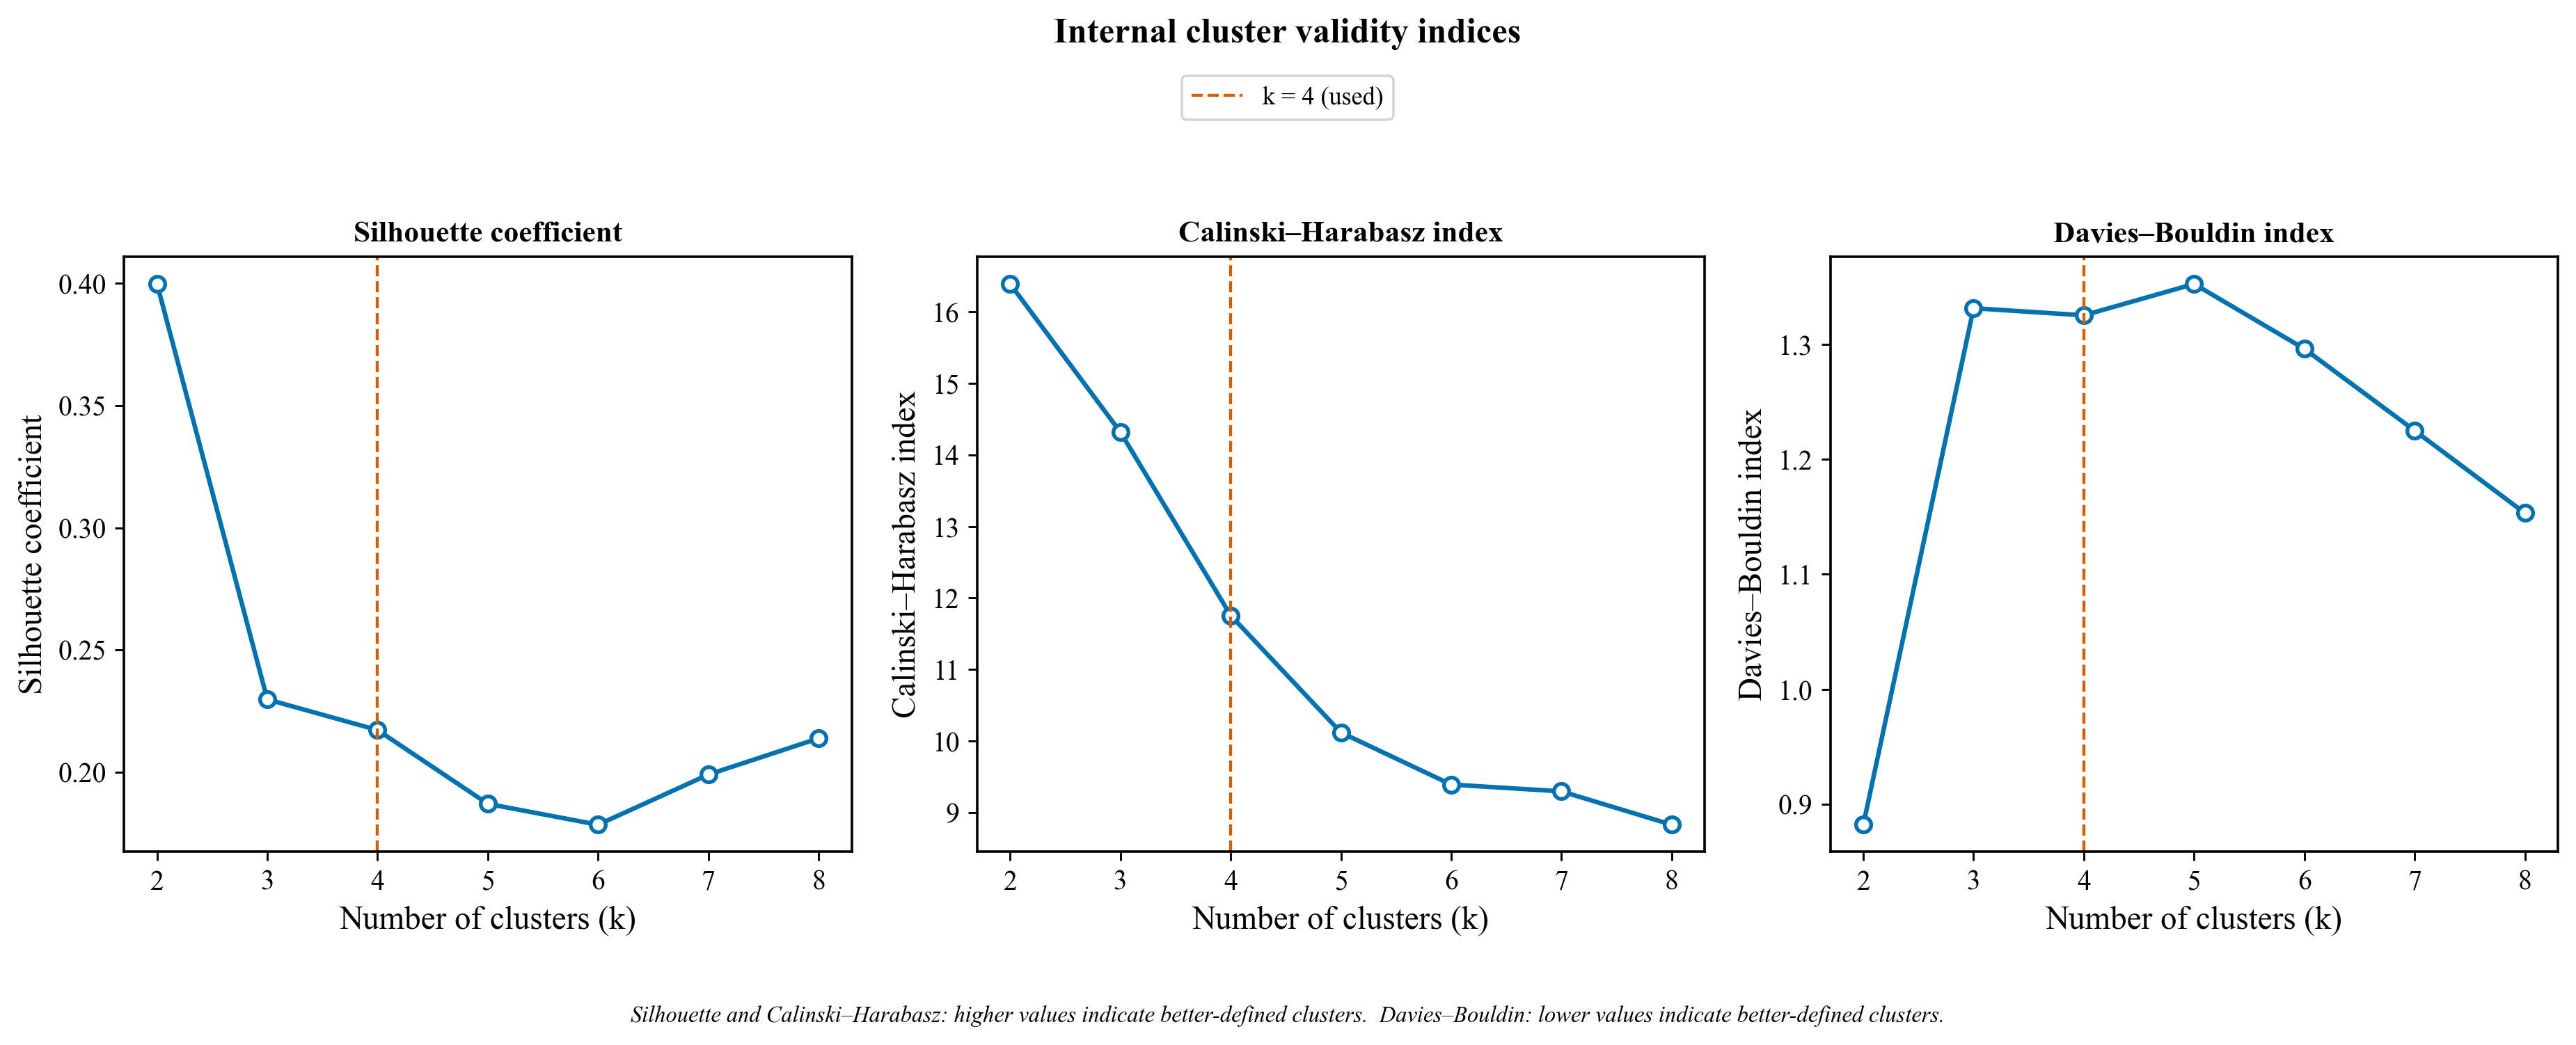

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(PANEL_W * 2.4, PANEL_H))
metrics = [
    ("silhouette", "Silhouette coefficient"),
    ("calinski_harabasz", "Calinski–Harabasz index"),
    ("davies_bouldin", "Davies–Bouldin index"),
]
for ax, (col, label) in zip(axes, metrics):
    line, = ax.plot(validity_table.index, validity_table[col], marker="o", color="#0072B2",
                     markerfacecolor="white", markeredgewidth=1.5, linewidth=1.8)
    vline = ax.axvline(N_CLUSTERS, color="#D55E00", linestyle="--", linewidth=1.2)
    ax.set_xlabel("Number of clusters (k)")
    ax.set_ylabel(label)
    ax.set_title(label, fontsize=12)
    ax.set_xticks(list(K_RANGE))
    closed_frame(ax)

fig.suptitle("Internal cluster validity indices", fontsize=14, fontweight="bold", y=1.05)
fig.legend([vline], [f"k = {N_CLUSTERS} (used)"], loc="upper center",
           bbox_to_anchor=(0.5, 1.0), ncol=1, frameon=True, fontsize=10,
           bbox_transform=fig.transFigure)
fig.text(0.5, -0.06,
         "Silhouette and Calinski–Harabasz: higher values indicate better-defined clusters.  "
         "Davies–Bouldin: lower values indicate better-defined clusters.",
         ha="center", fontsize=9, style="italic")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("fig1_internal_validity_indices.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

### Chunk 5 - Figure 2 - Gap Statistic

Plots the Gap Statistic curve with its standard-error bars across k = 2..8, marking both k = 4 (used in the manuscript) and the k actually selected by the Tibshirani criterion (the smallest k whose gap is within one standard error of the next k's gap), so the reader can see directly whether the two agree.

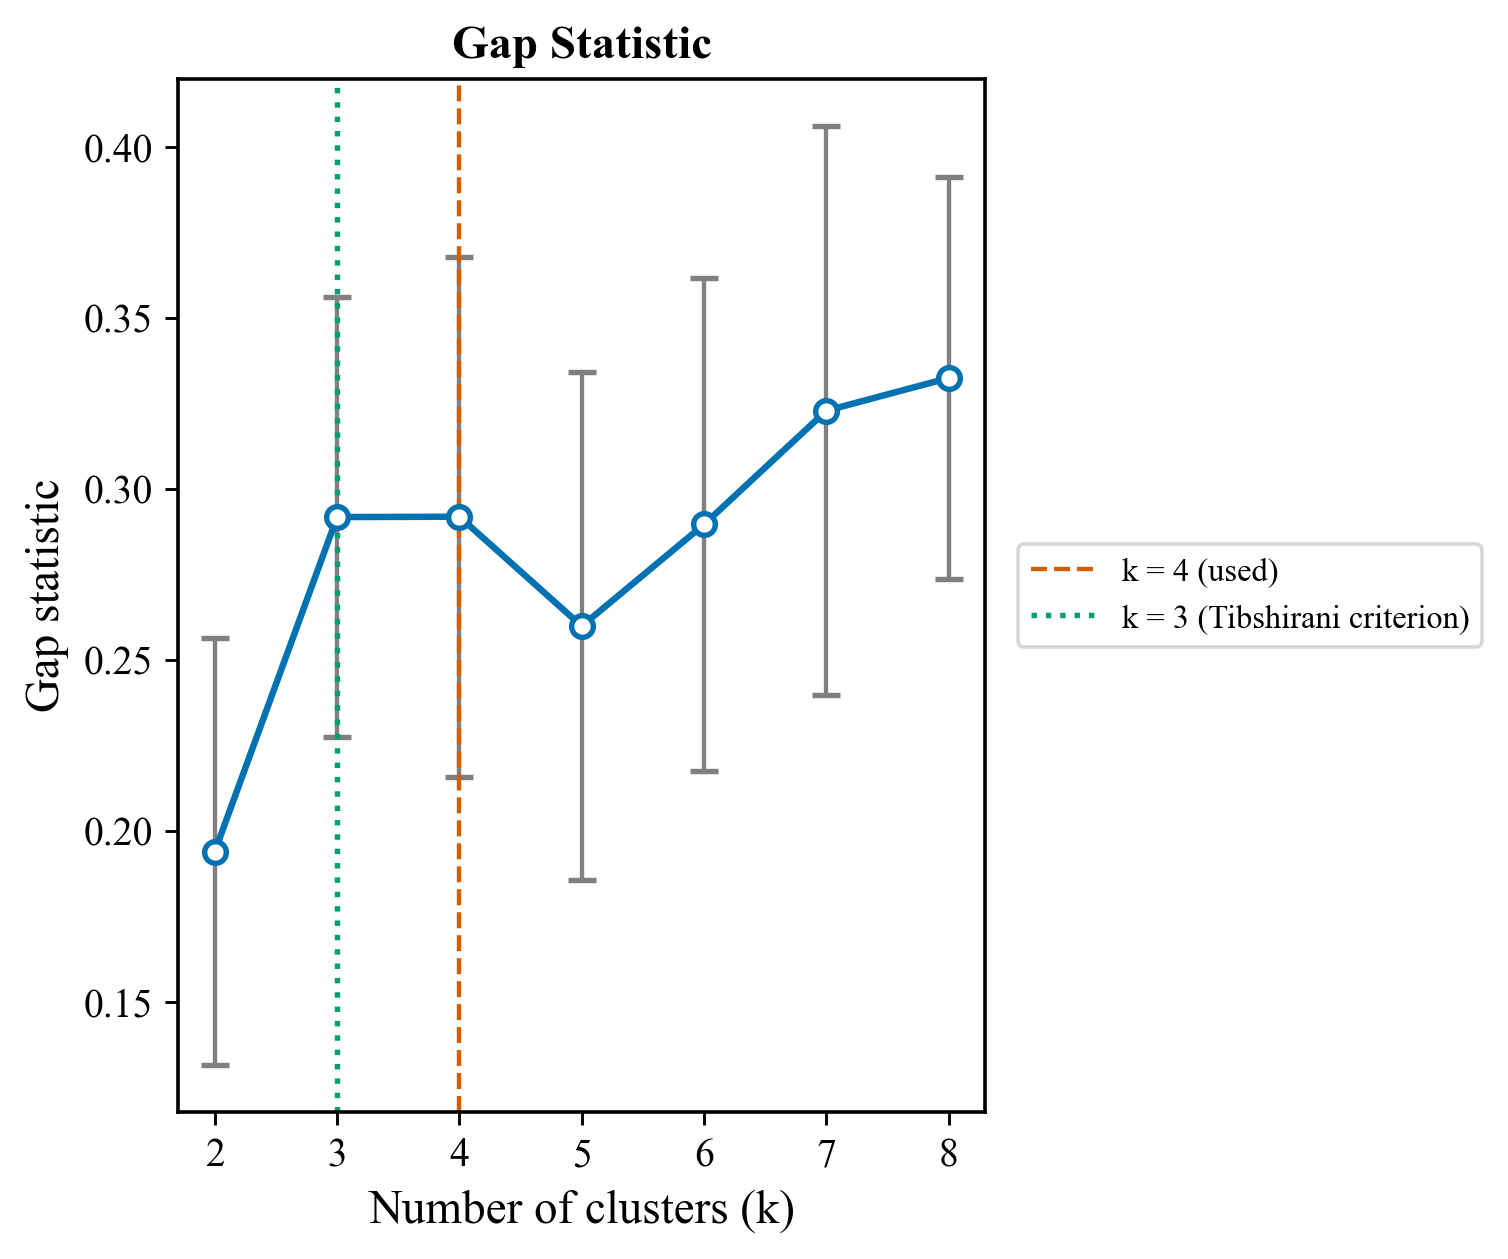

In [9]:
fig, ax = plt.subplots(figsize=(PANEL_W, PANEL_H))
ax.errorbar(gap_table.index, gap_table["gap"], yerr=gap_table["s_k"], fmt="o-",
            color="#0072B2", ecolor="grey", elinewidth=1.2, capsize=4,
            markerfacecolor="white", markeredgewidth=1.5, linewidth=1.8)
ax.axvline(N_CLUSTERS, color="#D55E00", linestyle="--", linewidth=1.2,
           label=f"k = {N_CLUSTERS} (used)")
if pd.notna(k_gap):
    ax.axvline(k_gap, color="#009E73", linestyle=":", linewidth=1.5,
               label=f"k = {int(k_gap)} (Tibshirani criterion)")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Gap statistic")
ax.set_title("Gap Statistic", fontsize=13)
ax.set_xticks(list(K_RANGE))
ax.legend(frameon=True, fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
closed_frame(ax)
plt.tight_layout()
plt.savefig("fig2_gap_statistic.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

### Chunk 6 - Figure 3 - Bootstrap cluster stability

One bar per cluster, showing its mean Jaccard similarity across the `N_BOOT` bootstrap resamples (error bars = standard deviation), against the Stable (>= 0.75) and Moderate (0.60-0.75) reference lines. The sample size and the global Adjusted Rand Index are reported once, as a caption below the figure, rather than inside the title.

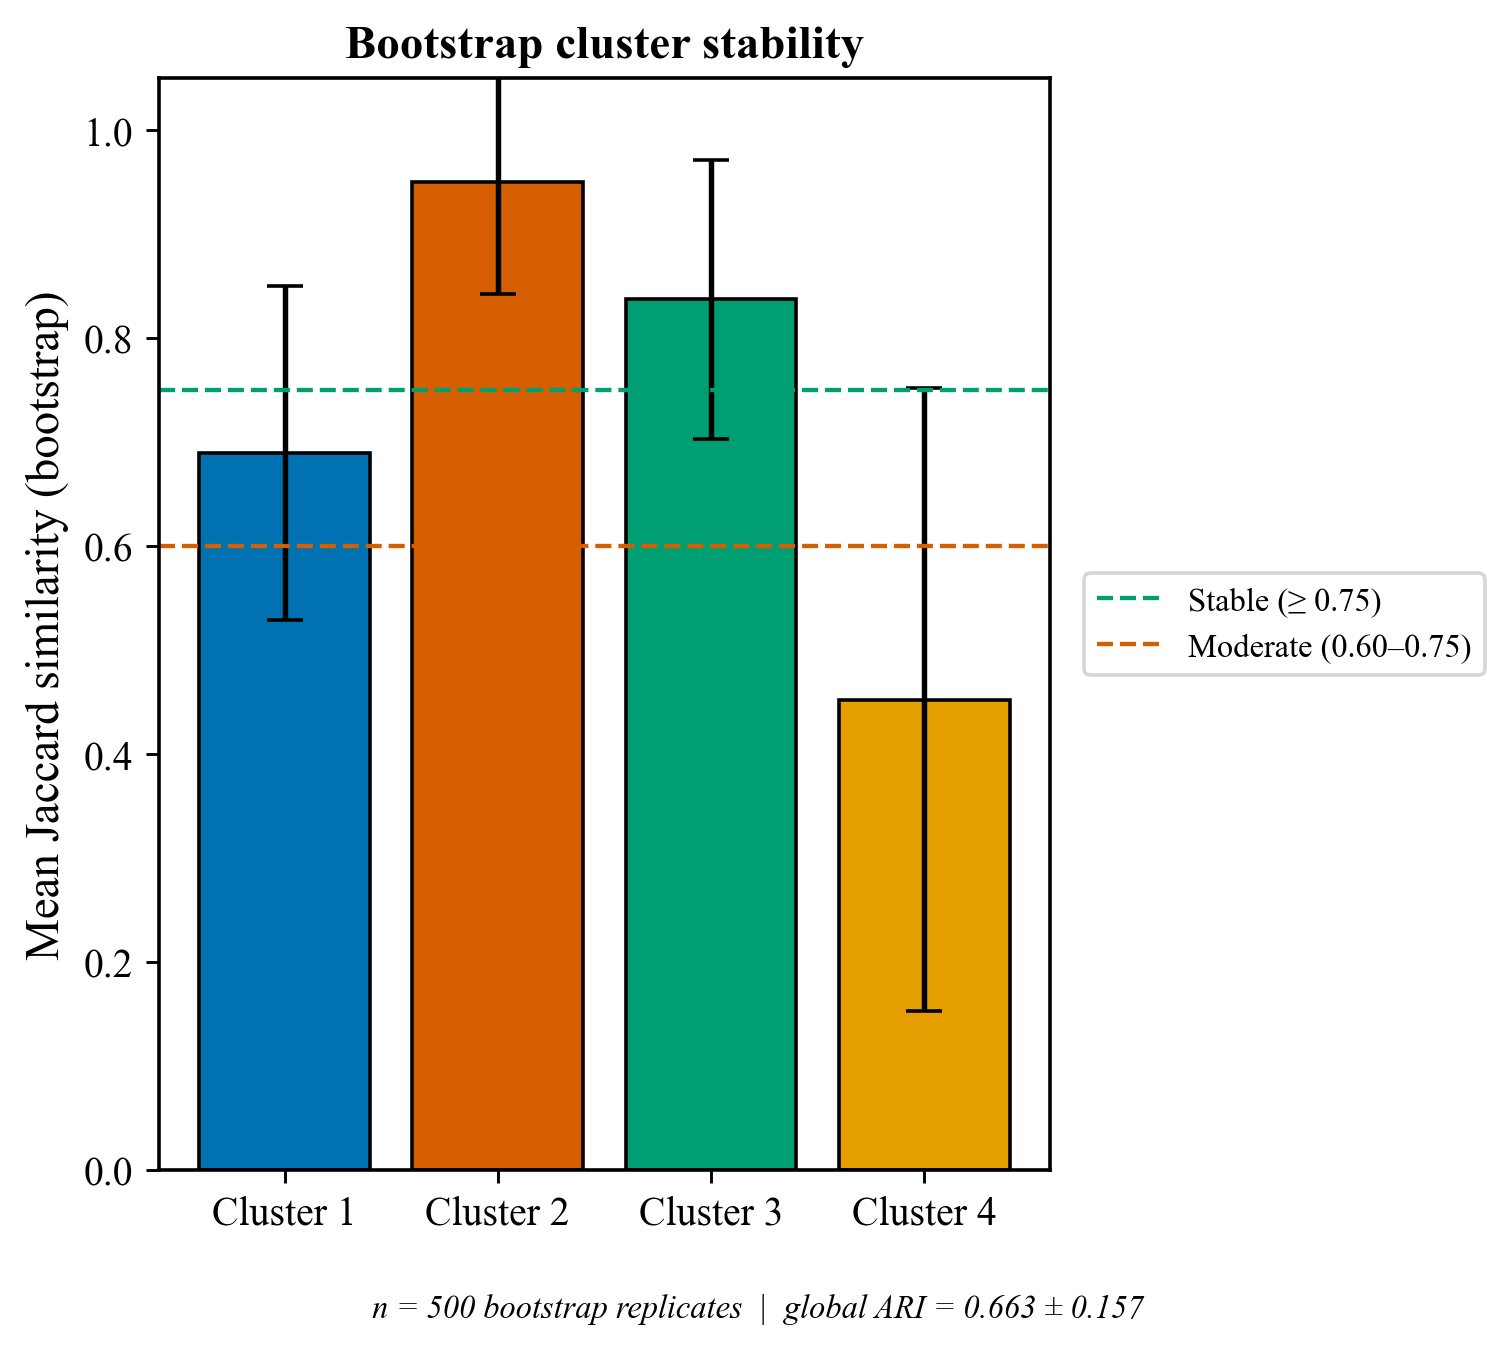

In [10]:
fig, ax = plt.subplots(figsize=(PANEL_W, PANEL_H))
x_pos = np.arange(N_CLUSTERS)
bars = ax.bar(x_pos, jaccard_mean, yerr=jaccard_sd, capsize=5,
              color=CLUSTER_COLORS[:N_CLUSTERS], edgecolor="black", linewidth=1.0)
ax.axhline(0.75, color="#009E73", linestyle="--", linewidth=1.2, label="Stable (≥ 0.75)")
ax.axhline(0.60, color="#D55E00", linestyle="--", linewidth=1.2, label="Moderate (0.60–0.75)")
ax.set_xticks(x_pos)
ax.set_xticklabels([f"Cluster {i + 1}" for i in range(N_CLUSTERS)])
ax.set_ylabel("Mean Jaccard similarity (bootstrap)")
ax.set_title("Bootstrap cluster stability", fontsize=13)
ax.set_ylim(0, 1.05)
ax.legend(frameon=True, fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.text(0.5, -0.03, f"n = {N_BOOT} bootstrap replicates  |  global ARI = {aris.mean():.3f} ± {aris.std():.3f}",
         ha="center", fontsize=9, style="italic")
closed_frame(ax)
plt.tight_layout()
plt.savefig("fig3_bootstrap_stability.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

### Chunk 7 - Figure 4 - Final clustering

Two panels:
- **Panel A**: the 29 genotypes on the PC1-PC2 plane, colored by their k-means cluster, each cluster surrounded by its 95% confidence ellipse, with genotype labels placed by `adjustText` so they do not overlap each other or the points.
- **Panel B**: the loading of each of the 15 variables on PC1 and PC2, showing which variables drive the separation seen in panel A.

This is the main figure used to report and interpret the final clustering (k = 4) in the manuscript.

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_316\2722028242.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


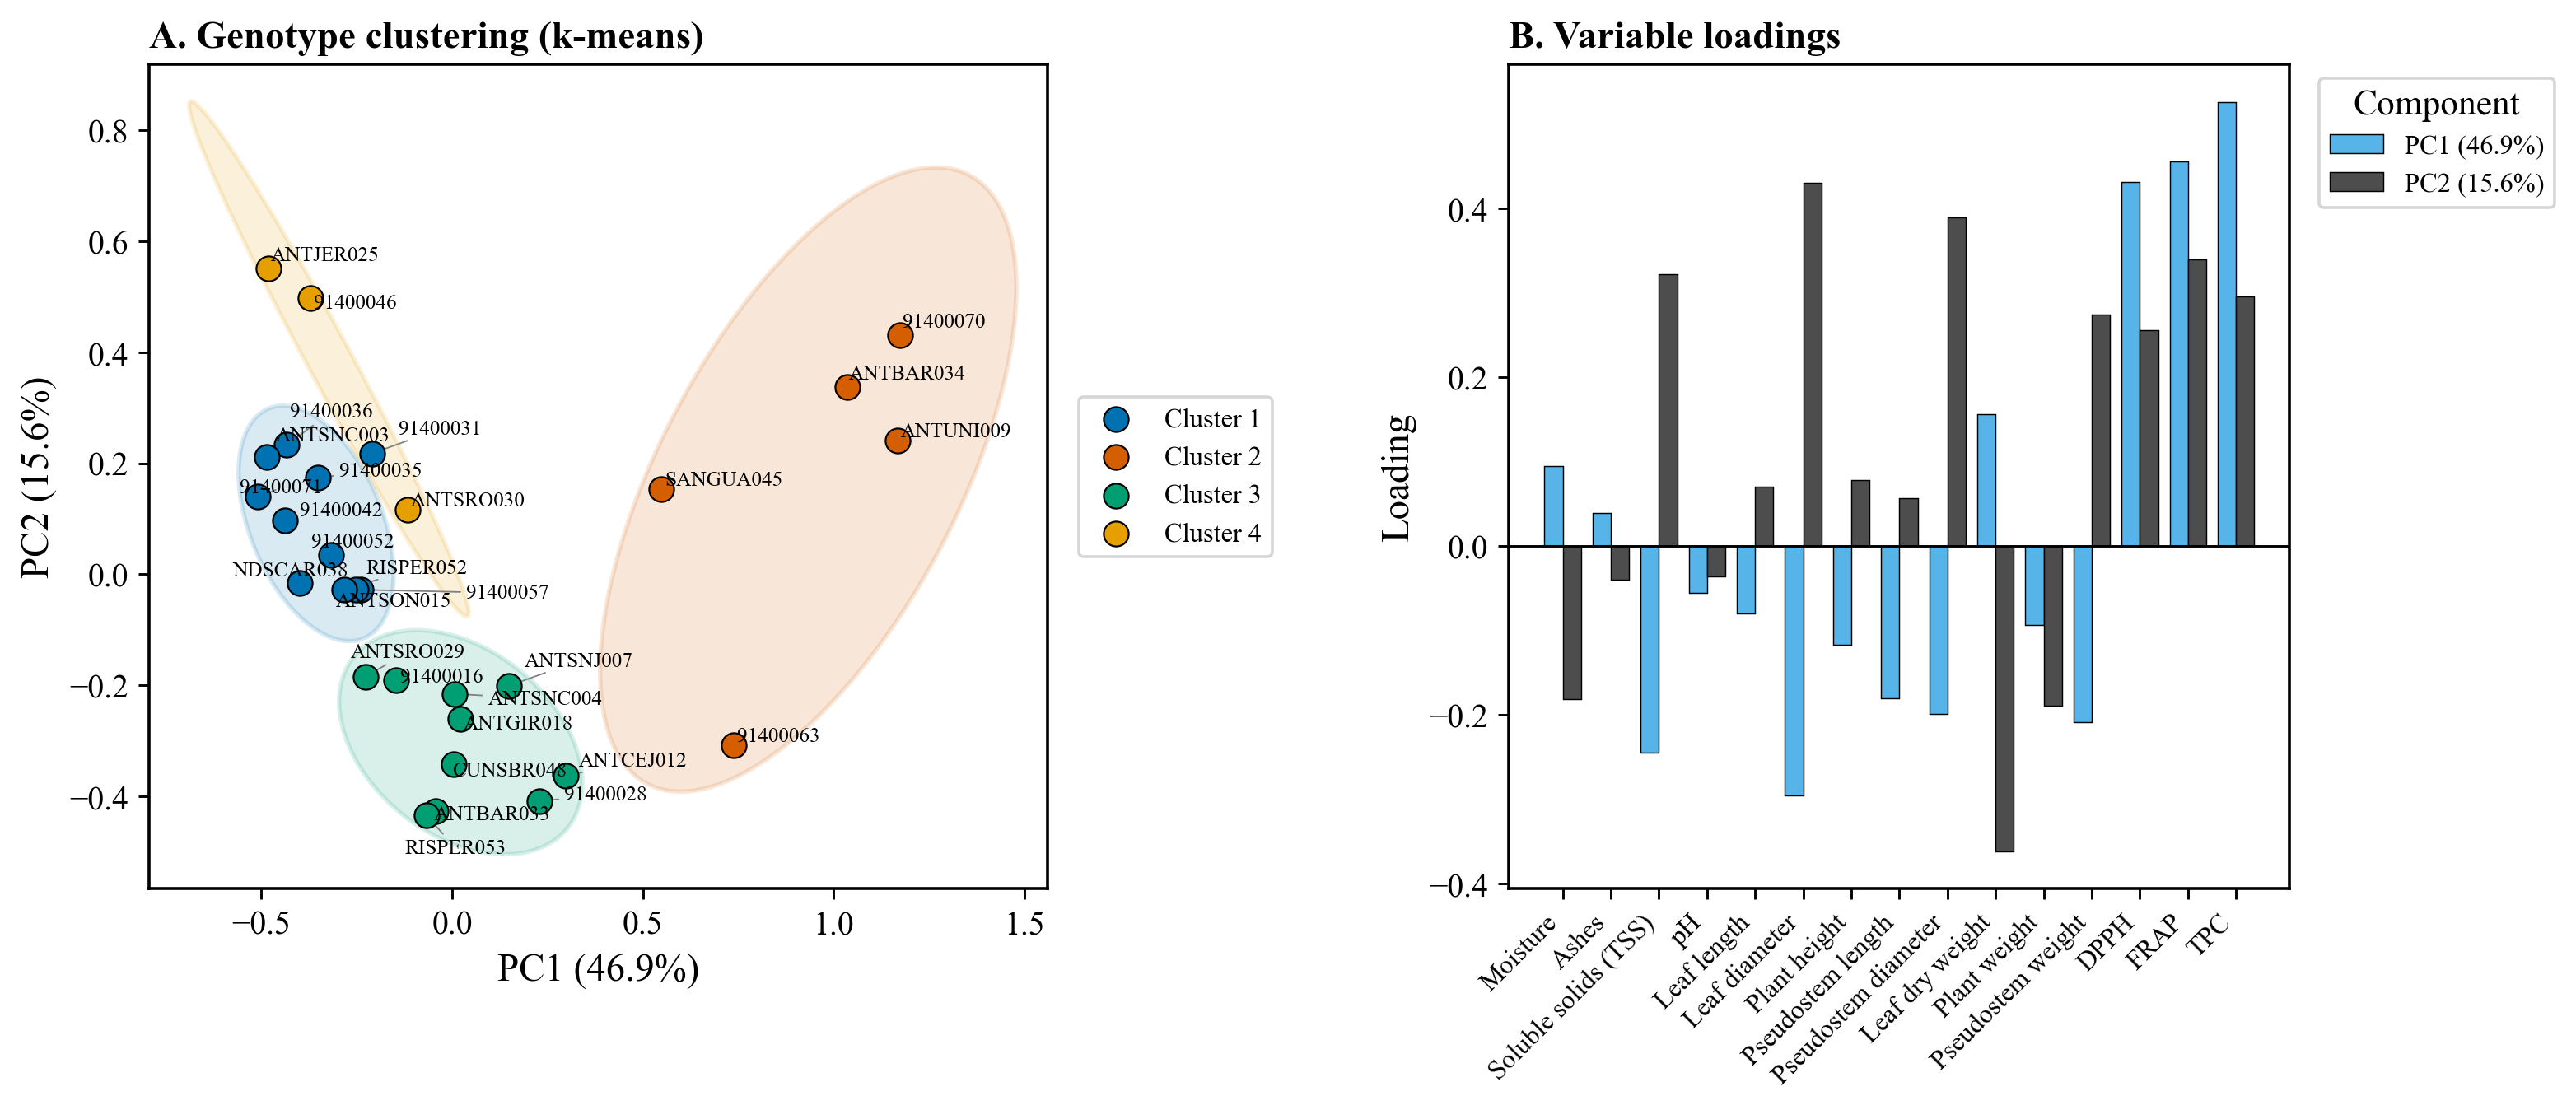

In [11]:
loadings = pca.components_.T
display_labels = [VARIABLE_LABELS[v] for v in VARIABLES]

fig = plt.figure(figsize=(PANEL_W * 2.15, PANEL_H))
gs = GridSpec(1, 2, width_ratios=[1.15, 1], wspace=0.55)
axA = fig.add_subplot(gs[0])
axB = fig.add_subplot(gs[1])

texts = []
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    x, y = scores[mask, 0], scores[mask, 1]
    color = CLUSTER_COLORS[c]
    axA.scatter(x, y, s=70, color=color, edgecolor="black", linewidth=0.6,
                label=f"Cluster {c + 1}", zorder=3)
    confidence_ellipse(x, y, axA, facecolor=color, alpha=0.15, edgecolor=color,
                        linewidth=1.5, zorder=1)
    for gx, gy, name in zip(x, y, genotypes[mask]):
        texts.append(axA.text(gx, gy, name, fontsize=7))

adjust_text(texts, ax=axA, arrowprops=dict(arrowstyle="-", color="grey", lw=0.5))
axA.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}%)")
axA.set_ylabel(f"PC2 ({explained_var[1]*100:.1f}%)")
axA.set_title("A. Genotype clustering (k-means)", fontsize=13, loc="left", fontweight="bold")
axA.legend(frameon=True, fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
closed_frame(axA)

x_bar = np.arange(len(VARIABLES))
width = 0.38
axB.bar(x_bar - width / 2, loadings[:, 0], width, label=f"PC1 ({explained_var[0]*100:.1f}%)",
        color=LOADING_COLORS[0], edgecolor="black", linewidth=0.4)
axB.bar(x_bar + width / 2, loadings[:, 1], width, label=f"PC2 ({explained_var[1]*100:.1f}%)",
        color=LOADING_COLORS[1], edgecolor="black", linewidth=0.4)
axB.axhline(0, color="black", linewidth=0.8)
axB.set_xticks(x_bar)
axB.set_xticklabels(display_labels, rotation=45, ha="right", fontsize=9)
axB.set_ylabel("Loading")
axB.set_title("B. Variable loadings", fontsize=13, loc="left", fontweight="bold")
axB.legend(frameon=True, fontsize=9, title="Component", loc="upper left", bbox_to_anchor=(1.02, 1.0))
closed_frame(axB)

plt.tight_layout()
plt.savefig("fig4_pca_clusters_loadings.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

### Chunk 8 - PLS-DA - descriptive only, not validation

PLS-DA is kept in the pipeline, but strictly repositioned: it is fit on the k-means cluster labels only to produce a supervised 2D projection (Figure 5) that visually separates the clusters, and to rank which variables contribute most to that separation (VIP scores, Figure 6). The balanced accuracy printed here describes how separable the clusters are in this projection - it is explicitly **not** an independent validation of the clustering, since the model is trained and evaluated on the very same labels it is supposed to "validate". The real validation is section 3 above.


[Descriptive PLS-DA] Balanced accuracy = 0.792 (describes how separable the k-means groups are in this space; it is NOT independent validation of the clustering)


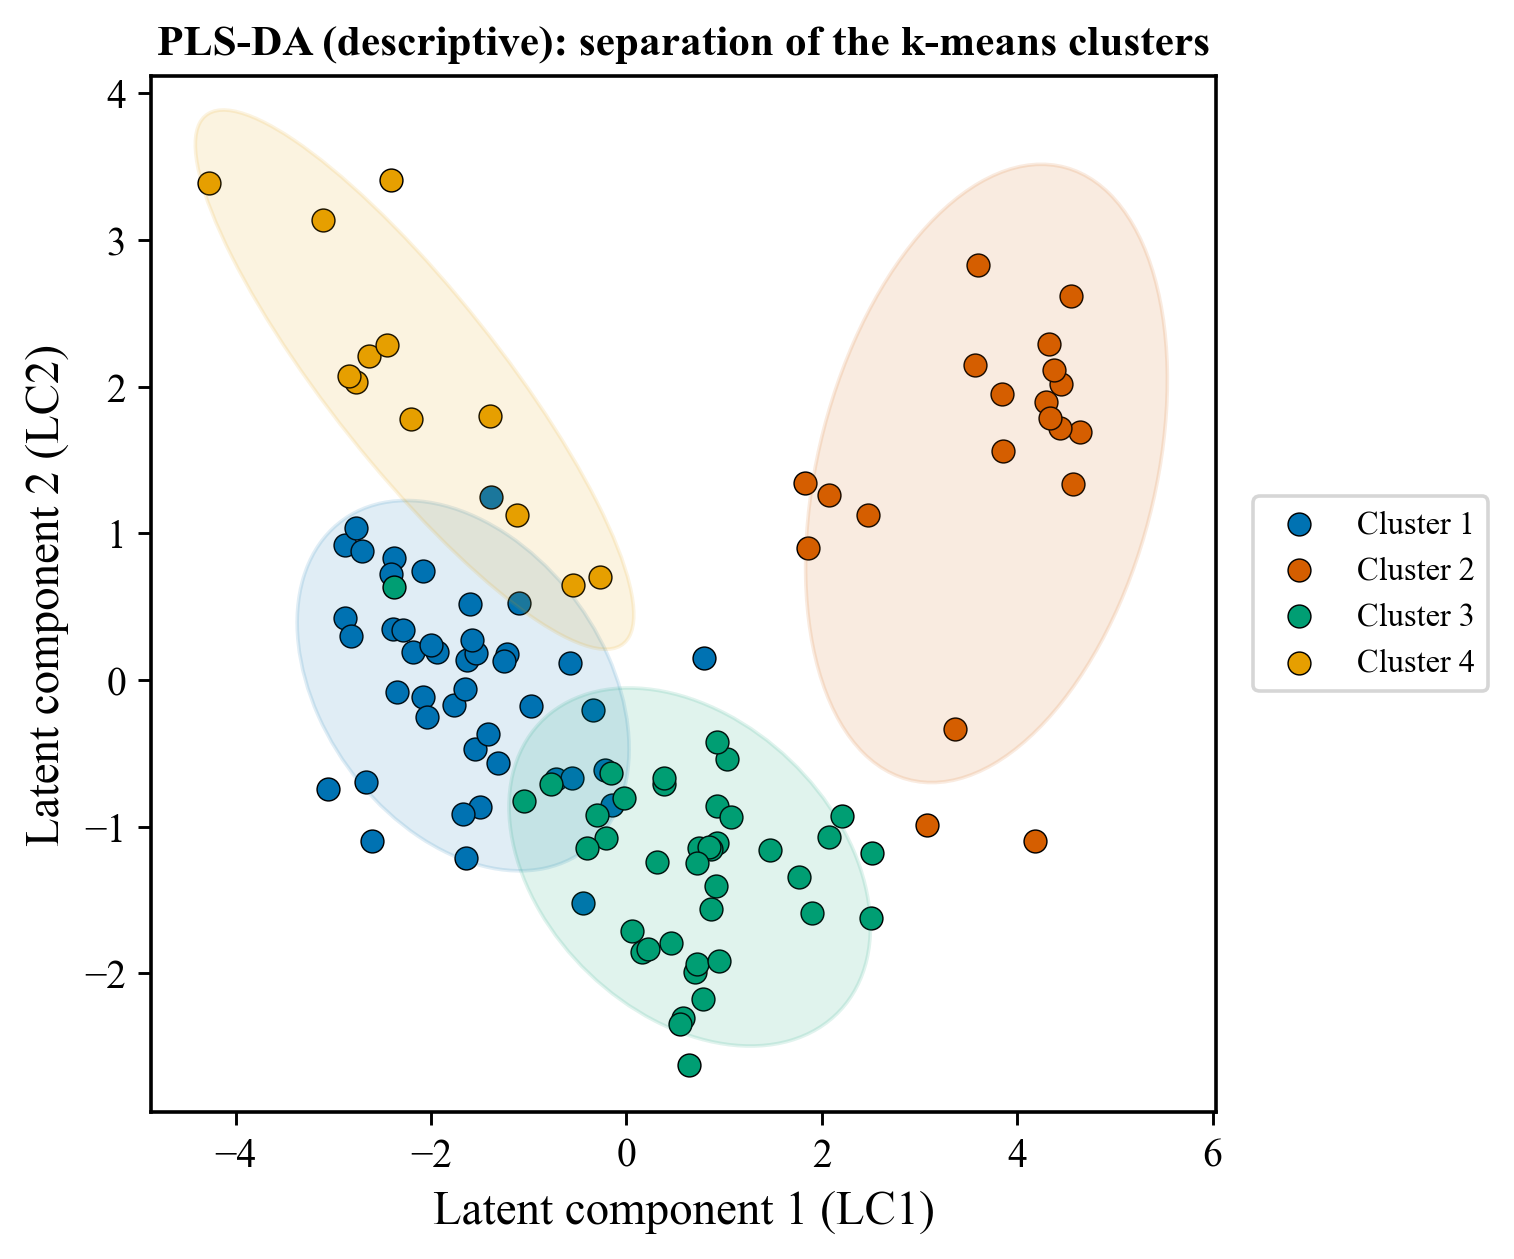

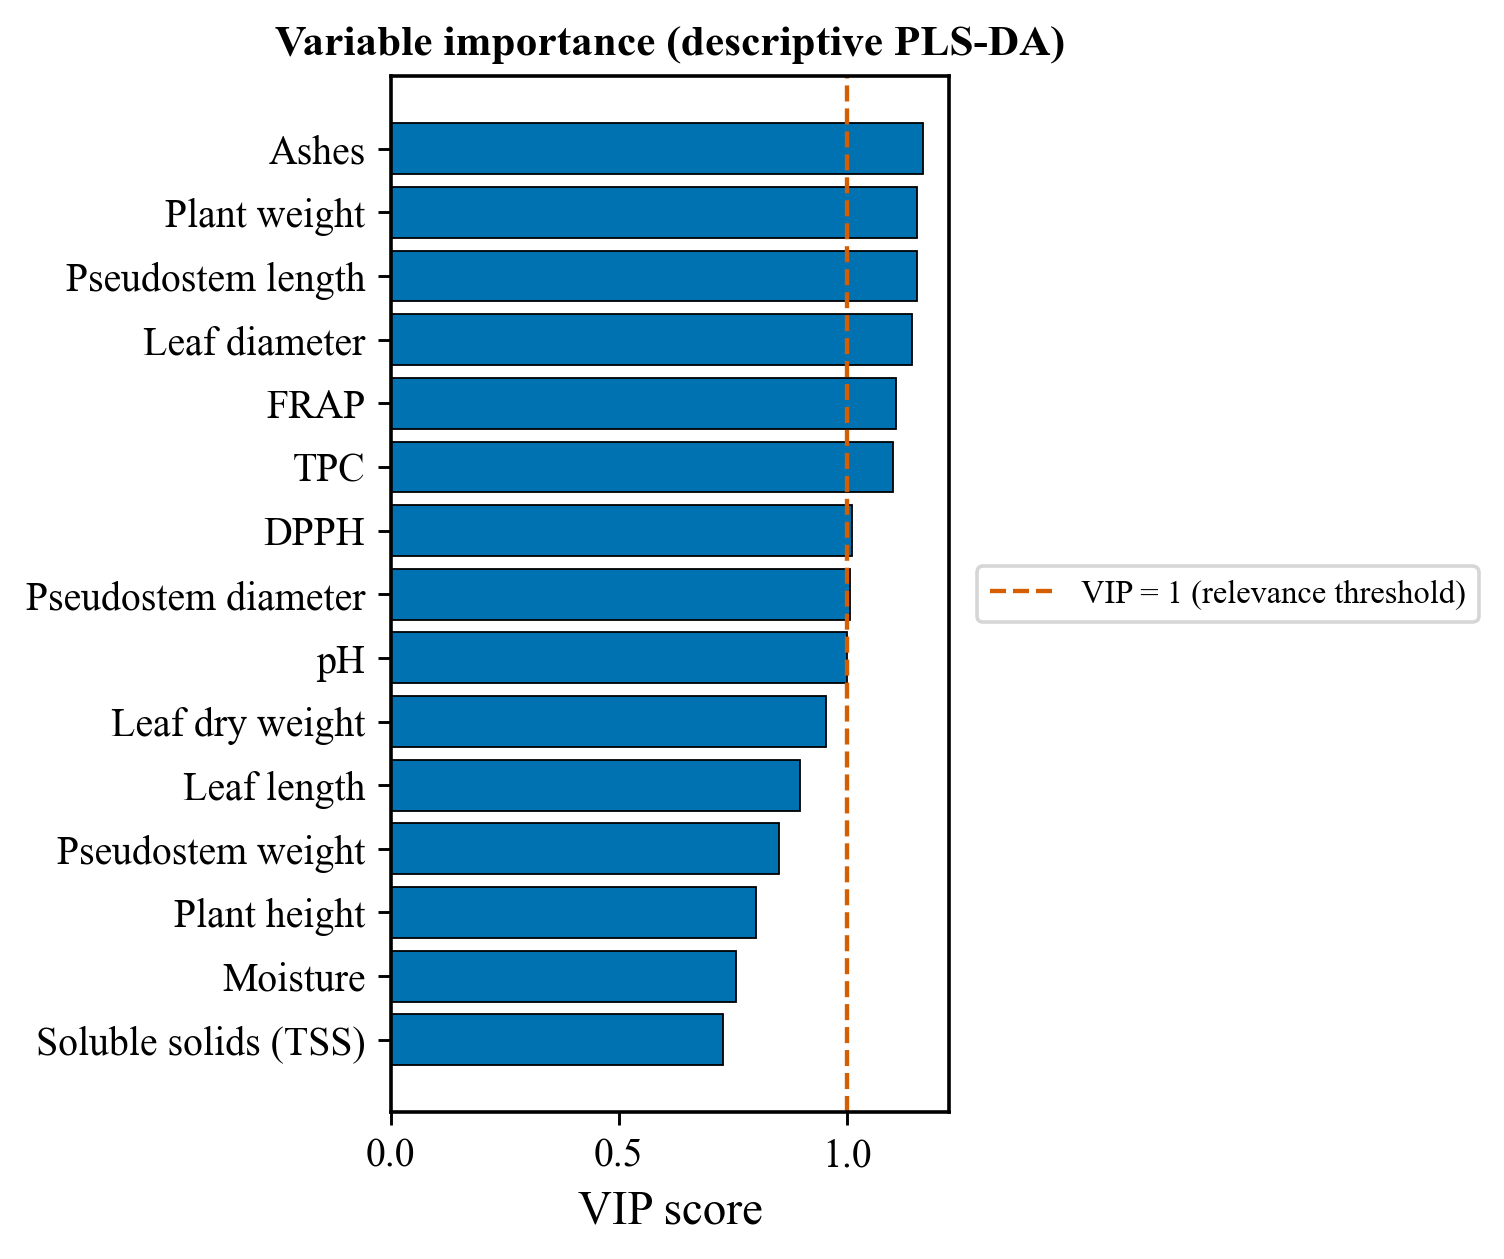

In [12]:
cluster_by_genotype = dict(zip(genotypes, cluster_labels))
data["cluster"] = data["genotype"].map(cluster_by_genotype)

X = data[VARIABLES]
y = data["cluster"].astype(str)
encoder = OneHotEncoder()
y_encoded = encoder.fit_transform(y.values.reshape(-1, 1)).toarray()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
pls = PLSRegression(n_components=min(11, X_train.shape[1]))
pls.fit(X_train, y_train)
y_pred_class = np.argmax(pls.predict(X_test), axis=1)
balanced_acc = balanced_accuracy_score(y_test.argmax(axis=1), y_pred_class)
print(f"\n[Descriptive PLS-DA] Balanced accuracy = {balanced_acc:.3f} "
      "(describes how separable the k-means groups are in this space; "
      "it is NOT independent validation of the clustering)")

X_scores = pls.x_scores_
cluster_train = data.loc[X_train.index, "cluster"].to_numpy()

fig, ax = plt.subplots(figsize=(PANEL_W, PANEL_H))
for c in range(N_CLUSTERS):
    mask = cluster_train == c
    ax.scatter(X_scores[mask, 0], X_scores[mask, 1], s=40, color=CLUSTER_COLORS[c],
               edgecolor="black", linewidth=0.4, label=f"Cluster {c + 1}")
    confidence_ellipse(X_scores[mask, 0], X_scores[mask, 1], ax,
                        facecolor=CLUSTER_COLORS[c], alpha=0.12, edgecolor=CLUSTER_COLORS[c])
ax.set_xlabel("Latent component 1 (LC1)")
ax.set_ylabel("Latent component 2 (LC2)")
ax.set_title("PLS-DA (descriptive): separation of the k-means clusters", fontsize=12)
ax.legend(frameon=True, fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
closed_frame(ax)
plt.tight_layout()
plt.savefig("fig5_plsda_descriptive.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

# VIP scores
W = pls.x_weights_
y_var_explained = np.sum(pls.y_scores_ ** 2, axis=0)
y_var_explained /= np.sum(y_var_explained)
p = X_train.shape[1]
VIP = np.sqrt(p * np.sum((W ** 2) * y_var_explained, axis=1))
vip_table = pd.DataFrame({"variable": [VARIABLE_LABELS[v] for v in X_train.columns], "VIP": VIP})
vip_table = vip_table.sort_values("VIP", ascending=True)

fig, ax = plt.subplots(figsize=(PANEL_W, PANEL_H))
ax.barh(vip_table["variable"], vip_table["VIP"], color="#0072B2", edgecolor="black", linewidth=0.5)
ax.axvline(1.0, color="#D55E00", linestyle="--", linewidth=1.2, label="VIP = 1 (relevance threshold)")
ax.set_xlabel("VIP score")
ax.set_title("Variable importance (descriptive PLS-DA)", fontsize=12)
ax.legend(frameon=True, fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
closed_frame(ax)
plt.tight_layout()
plt.savefig("fig6_vip_scores.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

### Chunk 9 - Genotypes closest to each cluster centroid

For every cluster, ranks its genotypes by Euclidean distance to the cluster's centroid in PCA space, and reports the closest ones. These are the most representative genotypes of each cluster - useful for picking the "contrasting subset" discussed in the manuscript.

In [13]:
def genotypes_near_centroid(scores, cluster_labels, genotypes, n_per_cluster=3):
    df = pd.DataFrame({"genotype": genotypes, "cluster": cluster_labels,
                        "PC1": scores[:, 0], "PC2": scores[:, 1]}).set_index("genotype")
    centroids = df.groupby("cluster")[["PC1", "PC2"]].mean()
    df["dist_to_centroid"] = df.apply(
        lambda row: np.linalg.norm(row[["PC1", "PC2"]].values - centroids.loc[row["cluster"]].values),
        axis=1
    )
    return df.sort_values(["cluster", "dist_to_centroid"]).groupby("cluster").head(n_per_cluster)


representative_genotypes = genotypes_near_centroid(scores, cluster_labels, genotypes, n_per_cluster=3)
print("\nGenotypes closest to each cluster centroid:")
print(representative_genotypes[["cluster", "dist_to_centroid"]])


Genotypes closest to each cluster centroid:
           cluster  dist_to_centroid
genotype                            
91400052         0          0.068788
91400042         0          0.082036
91400035         0          0.082700
ANTBAR034        1          0.195990
ANTUNI009        1          0.244790
91400070         1          0.354372
ANTGIR018        2          0.041581
CUNSBR048        2          0.043065
ANTSNC004        2          0.088371
91400046         3          0.119430
ANTJER025        3          0.226266
ANTSRO030        3          0.341057


### Chunk 10 - Export all result tables

Writes every table produced above into a single `phase1_validation_results.xlsx` file, one sheet per result: the internal validity indices, the Gap Statistic table, the bootstrap stability table, the final cluster assignments, the VIP scores, and the genotypes closest to each centroid.

In [14]:
with pd.ExcelWriter("phase1_validation_results.xlsx") as writer:
    validity_table.to_excel(writer, sheet_name="internal_validity_indices")
    gap_table.to_excel(writer, sheet_name="gap_statistic")
    pd.DataFrame({"cluster": range(1, N_CLUSTERS + 1), "jaccard_mean": jaccard_mean,
                  "jaccard_sd": jaccard_sd}).to_excel(writer, sheet_name="bootstrap_stability", index=False)
    pd.DataFrame({"genotype": genotypes, "cluster": cluster_labels + 1,
                  "PC1": scores[:, 0], "PC2": scores[:, 1]}).to_excel(
        writer, sheet_name="final_clusters", index=False)
    vip_table.sort_values("VIP", ascending=False).to_excel(writer, sheet_name="VIP_scores", index=False)
    representative_genotypes.to_excel(writer, sheet_name="representative_genotypes")

print(f"\nDone. Figures: fig1-fig6 (.png, {SAVE_DPI} dpi). Tables: phase1_validation_results.xlsx")


Done. Figures: fig1-fig6 (.png, 400 dpi). Tables: phase1_validation_results.xlsx
